# EDA — `combined` dataset (v2: whole-day split)

Gold (route 29) + Green (route 17) + Red (route 20), March 2026 scrapes. **Clough is excluded** from
`combined`: its stop ID can't be recovered causally (the causal next-stop guess only matches TransLoc's
own stop 75.6% of the time on Red, below the 80% acceptance bar — see `datasets/build_report.md`); it
stays in `raw_data` only.

Follows `plan/03_eda/01_eda_spec.md` sections E1-E10 (v2). Split is by **whole service day** (test days
2026-03-04 and 2026-03-09); `cv_group` (train-only tuning groups) is the date. Fences/pruning are fit on
**train only**; per v2, target-outlier rows are dropped from **train only** — test rows are never filtered
by their own label, only reported.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

from mc_common import load_features, save_model_ready, load_model_ready, iqr_fences, high_corr_pairs, prune_correlated

DS = "combined"

## E1 — Load

In [2]:
df, schema = load_features(DS)
target = schema["target"]
features = list(schema["features"])
meta = list(schema["meta"])

print("shape:", df.shape)
print("target:", target)
print("n features:", len(features))
print("n meta:", len(meta))
print()
print(df.dtypes.value_counts())
df.head()

shape: (110569, 63)
target: delay_s
n features: 54
n meta: 8

int64             24
float64           24
float32            8
str                4
int32              2
datetime64[ns]     1
Name: count, dtype: int64


,t_local,date,route_name,route_id,vehicle_id,route_stop_id,split,cv_group,eta_s,eta_delta_s,eta_prev_missing,eta_frozen_polls,dist_to_stop_m,stops_ahead,planned_s_ahead,since_last_arrival_s,planned_remaining_s,vehicle_speed,speed_mean_2min,stationary_s,stale_gps,vehicle_lat,vehicle_lon,n_buses_active,hour,minute_of_day,tod_sin,tod_cos,stop_lat,stop_lon,stop_rank_frac,stop_planned_dwell_s,temp_f,apparent_temp_f,rel_humidity,precip_in,rain_in,cloud_cover,wind_mph,wind_gust_mph,precip_prev_1h,is_raining,wx_clear,wx_cloudy,wx_drizzle,wx_rain,wx_snow,dow_Friday,dow_Monday,dow_Thursday,dow_Tuesday,route_Gold,route_Green,route_Red,vehicle_emb_0,vehicle_emb_1,vehicle_emb_2,vehicle_emb_3,stop_emb_0,stop_emb_1,stop_emb_2,stop_emb_3,delay_s
0,2026-03-06 08:45:26.312096,2026-03-06,Gold,29,10,421,train,2026-03-06,56.0,-34.0,0,0.0,293.267710,18,1573,36.861412,1536.138588,3.999642,6.999374,0.0,0,33.774380,-84.402530,3,8,525,0.750592,-0.660766,33.773404,-84.399583,0.952381,10,60.1,61.1,95,0.0,0.0,10,4.3,8.1,0.0,0,1,0,0,0,0,1,0,0,0,1,0,0,-0.72829,1.092901,0.854775,1.613671,0.745980,1.465911,0.315706,0.552305,32.683992
1,2026-03-06 08:45:26.312096,2026-03-06,Gold,29,10,420,train,2026-03-06,355.0,-34.0,0,0.0,327.965754,20,1872,36.861412,1835.138588,3.999642,6.999374,0.0,0,33.774380,-84.402530,3,8,525,0.750592,-0.660766,33.773428,-84.399173,0.047619,10,60.1,61.1,95,0.0,0.0,10,4.3,8.1,0.0,0,1,0,0,0,0,1,0,0,0,1,0,0,-0.72829,1.092901,0.854775,1.613671,0.259477,-0.178709,-1.229060,-0.126511,-257.316211
2,2026-03-06 08:45:56.317523,2026-03-06,Gold,29,10,420,train,2026-03-06,334.0,-21.0,0,0.0,221.890309,20,1872,66.866839,1805.133161,18.000626,9.666547,0.0,0,33.773750,-84.401540,3,8,525,0.749148,-0.662402,33.773428,-84.399173,0.047619,10,60.1,61.1,95,0.0,0.0,10,4.3,8.1,0.0,0,1,0,0,0,0,1,0,0,0,1,0,0,-0.72829,1.092901,0.854775,1.613671,0.259477,-0.178709,-1.229060,-0.126511,-266.321638
3,2026-03-06 08:45:56.317523,2026-03-06,Gold,29,10,421,train,2026-03-06,35.0,-21.0,0,0.0,185.082111,18,1573,66.866839,1506.133161,18.000626,9.666547,0.0,0,33.773750,-84.401540,3,8,525,0.749148,-0.662402,33.773404,-84.399583,0.952381,10,60.1,61.1,95,0.0,0.0,10,4.3,8.1,0.0,0,1,0,0,0,0,1,0,0,0,1,0,0,-0.72829,1.092901,0.854775,1.613671,0.745980,1.465911,0.315706,0.552305,23.678565
4,2026-03-06 08:46:54.996088,2026-03-06,Gold,29,10,420,train,2026-03-06,299.0,-35.0,0,0.0,38.034307,20,1872,125.545404,1746.454596,0.000000,7.333423,0.0,0,33.773404,-84.399583,3,8,526,0.746348,-0.665556,33.773428,-84.399173,0.047619,10,60.1,61.1,95,0.0,0.0,10,4.3,8.1,0.0,0,1,0,0,0,0,1,0,0,0,1,0,0,-0.72829,1.092901,0.854775,1.613671,0.259477,-0.178709,-1.229060,-0.126511,-290.000203


## E2 — Data quality

In [3]:
n_null_features = int(df[features].isna().sum().sum())
n_null_target = int(df[target].isna().sum())
print("nulls in features:", n_null_features)
print("nulls in target:", n_null_target)
assert n_null_features == 0, "nulls found in features"
assert n_null_target == 0, "nulls found in target"

const_features = [c for c in features if df[c].nunique(dropna=False) <= 1]
print("constant features (whole df):", const_features)
assert not const_features, f"unexpected constant features: {const_features}"

dup_rows = int(df.duplicated().sum())
print("duplicate rows:", dup_rows)

print()
print("split sizes:")
print(df["split"].value_counts())
print()
print("train days:", sorted(df.loc[df["split"] == "train", "date"].unique().tolist()))
print("test days:", sorted(df.loc[df["split"] == "test", "date"].unique().tolist()))
print("cv_group nunique (train):", df.loc[df["split"] == "train", "cv_group"].nunique())
print("cv_group nunique (test):", df.loc[df["split"] == "test", "cv_group"].nunique())
print()
print("rows per day:")
print(df.groupby("date").size())
print()
print("rows per vehicle:")
print(df.groupby("vehicle_id").size())
print()
print("rows per route:")
print(df.groupby("route_name").size())

nulls in features: 0
nulls in target: 0
constant features (whole df): []


duplicate rows: 0

split sizes:
split
train    81428
test     29141
Name: count, dtype: int64

train days: ['2026-03-03', '2026-03-05', '2026-03-06', '2026-03-10', '2026-03-16']
test days: ['2026-03-04', '2026-03-09']
cv_group nunique (train): 5
cv_group nunique (test): 2

rows per day:
date
2026-03-03     5335
2026-03-04    12143
2026-03-05    31191
2026-03-06     1002
2026-03-09    16998
2026-03-10    25032
2026-03-16    18868
dtype: int64

rows per vehicle:
vehicle_id
1      1592
3     26661
4      1267
5     10794
6      2065
7      1898
9      8576
10     8276
11     1271
13     5181
14      399
15      900
16     5673
33     6682
34     7384
37     5007
38    13697
41     3246
dtype: int64

rows per route:
route_name
Gold     36218
Green    60898
Red      13453
dtype: int64


## E3 — Target (`delay_s`)

count    110569.000000
mean        299.494232
std         326.308341
min       -1295.457351
25%          42.006869
50%         229.317411
75%         484.091390
max        2697.000000
Name: delay_s, dtype: float64
skew: 1.1201
kurtosis: 2.5091


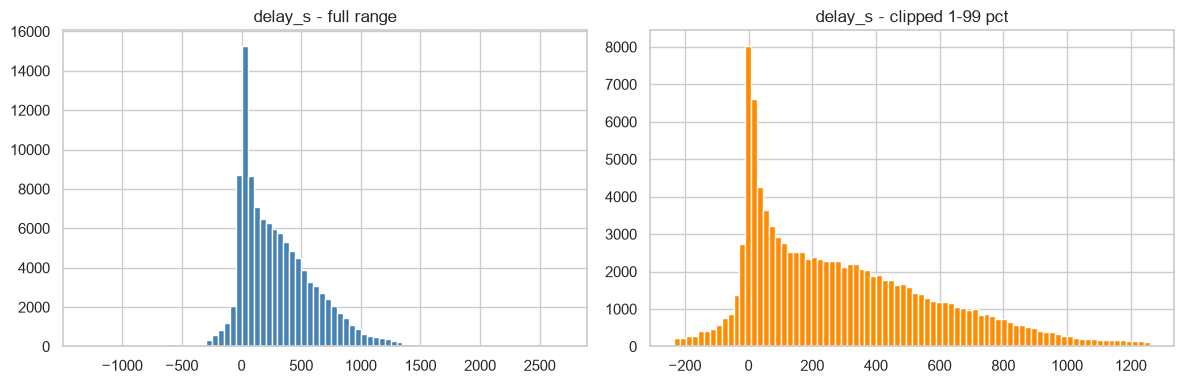

C:\Users\danma\AppData\Local\Temp\ipykernel_19392\3109084601.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(y, vert=False)


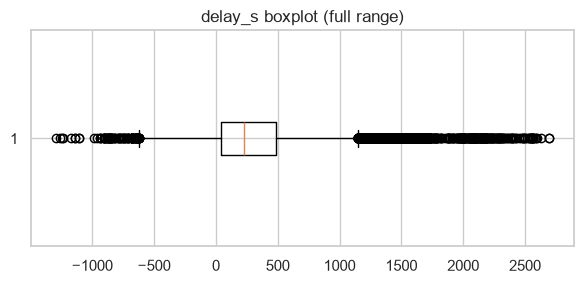

            mean      median  count
hour                               
6     127.646207   82.012932    401
7     220.390246  148.027989   1835
8     235.766388  137.017017   3589
9     264.473332  111.045639   4919
10    236.430700  155.892789   4873
11    199.841112  115.009869   5868
12    277.089451  241.015087   8359
13    278.459112  221.007171   6063
14    229.949651  172.814392   6290
15    255.930771  157.011826   4102
16    347.162221  290.035612  15596
17    420.407612  322.033617  12359
18    379.048007  316.387910  11969
19    256.075794  225.257993   9138
20    272.152290  210.148349  10015
21    321.260896  255.022962   3855
22    219.121905  100.006068   1019
23     38.290068    4.000000    319

                  mean      median  count
date                                     
2026-03-03   71.978232    7.178209   5335
2026-03-04  175.695030   43.007831  12143
2026-03-05  325.632215  263.147467  31191
2026-03-06   18.488693   23.034047   1002
2026-03-09  281.073075  243

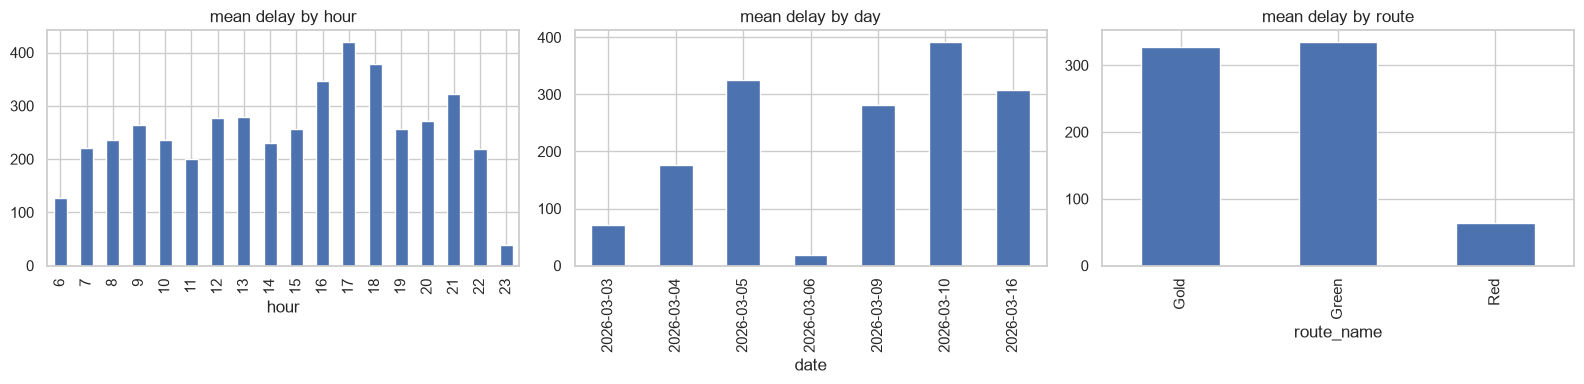

In [4]:
y = df[target]
print(y.describe())
print("skew:", round(float(y.skew()), 4))
print("kurtosis:", round(float(y.kurtosis()), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=80, color="steelblue")
axes[0].set_title(f"{target} - full range")
lo_c, hi_c = y.quantile([0.01, 0.99])
clipped = y[(y >= lo_c) & (y <= hi_c)]
axes[1].hist(clipped, bins=80, color="darkorange")
axes[1].set_title(f"{target} - clipped 1-99 pct")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
ax.boxplot(y, vert=False)
ax.set_title(f"{target} boxplot (full range)")
plt.tight_layout(); plt.show()

by_hour = df.groupby("hour")[target].agg(["mean", "median", "count"])
by_day = df.groupby("date")[target].agg(["mean", "median", "count"])
by_route = df.groupby("route_name")[target].agg(["mean", "median", "count"])
print(by_hour)
print()
print(by_day)
print()
print(by_route)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
by_hour["mean"].plot(kind="bar", ax=axes[0], title="mean delay by hour")
by_day["mean"].plot(kind="bar", ax=axes[1], title="mean delay by day")
by_route["mean"].plot(kind="bar", ax=axes[2], title="mean delay by route")
plt.tight_layout(); plt.show()

## E4 — Target outliers (v2: train-only drop)

Fences fit on **train** only (`iqr_fences(k=3.0)`). **v2 rule**: drop rows outside `[lo, hi]` from
**TRAIN only**. Test rows are never filtered by their own label — extreme *training* values are mostly
label errors from missed arrival detections (~one lap); filtering test by label would flatter the
metrics. We still count and report how many test rows would fall outside the (train-fit) fences.

fences (train, k=3.0): lo=-1340.2  hi=1910.7
train outliers: 170 / 81428  (0.21%)
test rows outside train fences (NOT dropped, report only): 9 / 29141  (0.03%)


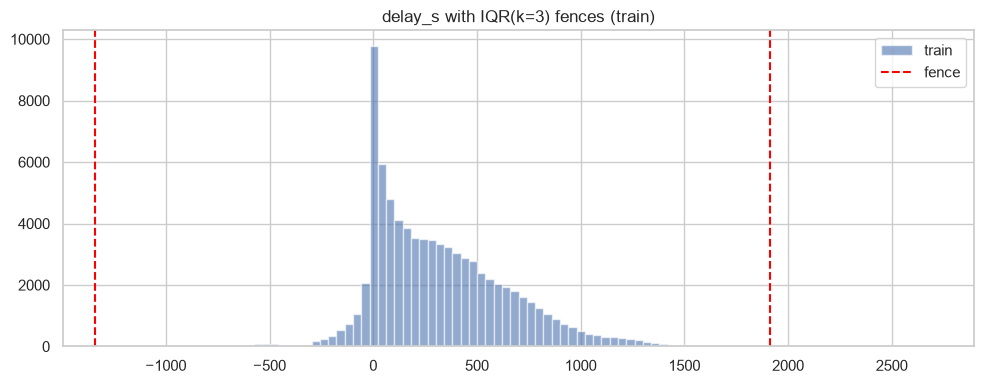

dropped 170 train rows (of 81428); kept all 29141 test rows unchanged
kept 110399 of 110569 rows total
train2: (81258, 63)  test2: (29141, 63)


In [5]:
train = df[df["split"] == "train"].reset_index(drop=True)
test = df[df["split"] == "test"].reset_index(drop=True)

lo, hi = iqr_fences(train[target], k=3.0)
print(f"fences (train, k=3.0): lo={lo:.1f}  hi={hi:.1f}")

train_out_mask = (train[target] < lo) | (train[target] > hi)
train_out = int(train_out_mask.sum())
test_out_mask = (test[target] < lo) | (test[target] > hi)
test_out = int(test_out_mask.sum())
print(f"train outliers: {train_out} / {len(train)}  ({train_out/len(train):.2%})")
print(f"test rows outside train fences (NOT dropped, report only): {test_out} / {len(test)}  ({test_out/len(test):.2%})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train[target], bins=100, alpha=0.6, label="train")
ax.axvline(lo, color="red", ls="--", label="fence")
ax.axvline(hi, color="red", ls="--")
ax.legend(); ax.set_title("delay_s with IQR(k=3) fences (train)")
plt.tight_layout(); plt.show()

# v2: drop outlier rows from TRAIN only; keep ALL test rows untouched
train2 = train[~train_out_mask].reset_index(drop=True)
test2 = test.copy()
df2 = pd.concat([train2, test2], ignore_index=True)
print(f"dropped {train_out} train rows (of {len(train)}); kept all {len(test2)} test rows unchanged")
print(f"kept {len(df2)} of {len(df)} rows total")
print("train2:", train2.shape, " test2:", test2.shape)

## E5 — Feature outliers (report only, no dropping)

In [6]:
rows = []
for c in features:
    flo, fhi = iqr_fences(train2[c], k=3.0)
    n_out = int(((train2[c] < flo) | (train2[c] > fhi)).sum())
    rows.append({"feature": c, "lo": flo, "hi": fhi, "n_outliers": n_out, "pct": round(n_out / len(train2), 4)})
feat_outliers = pd.DataFrame(rows).sort_values("n_outliers", ascending=False).reset_index(drop=True)
pd.set_option("display.max_rows", 100)
feat_outliers

,feature,lo,hi,n_outliers,pct
0,dow_Monday,0.000000,0.000000,18868,0.2322
1,wx_cloudy,0.000000,0.000000,14361,0.1767
2,stationary_s,-45.003896,60.005195,12693,0.1562
3,route_Red,0.000000,0.000000,8207,0.1010
4,stop_planned_dwell_s,-30.000000,40.000000,7517,0.0925
5,precip_prev_1h,-0.036000,0.048000,7162,0.0881
6,eta_frozen_polls,-6.000000,8.000000,6576,0.0809
7,precip_in,-0.036000,0.048000,4390,0.0540
8,wx_rain,0.000000,0.000000,4390,0.0540
9,rain_in,-0.036000,0.048000,4390,0.0540


## E6 — Correlation (train, post train-only target-outlier filtering)

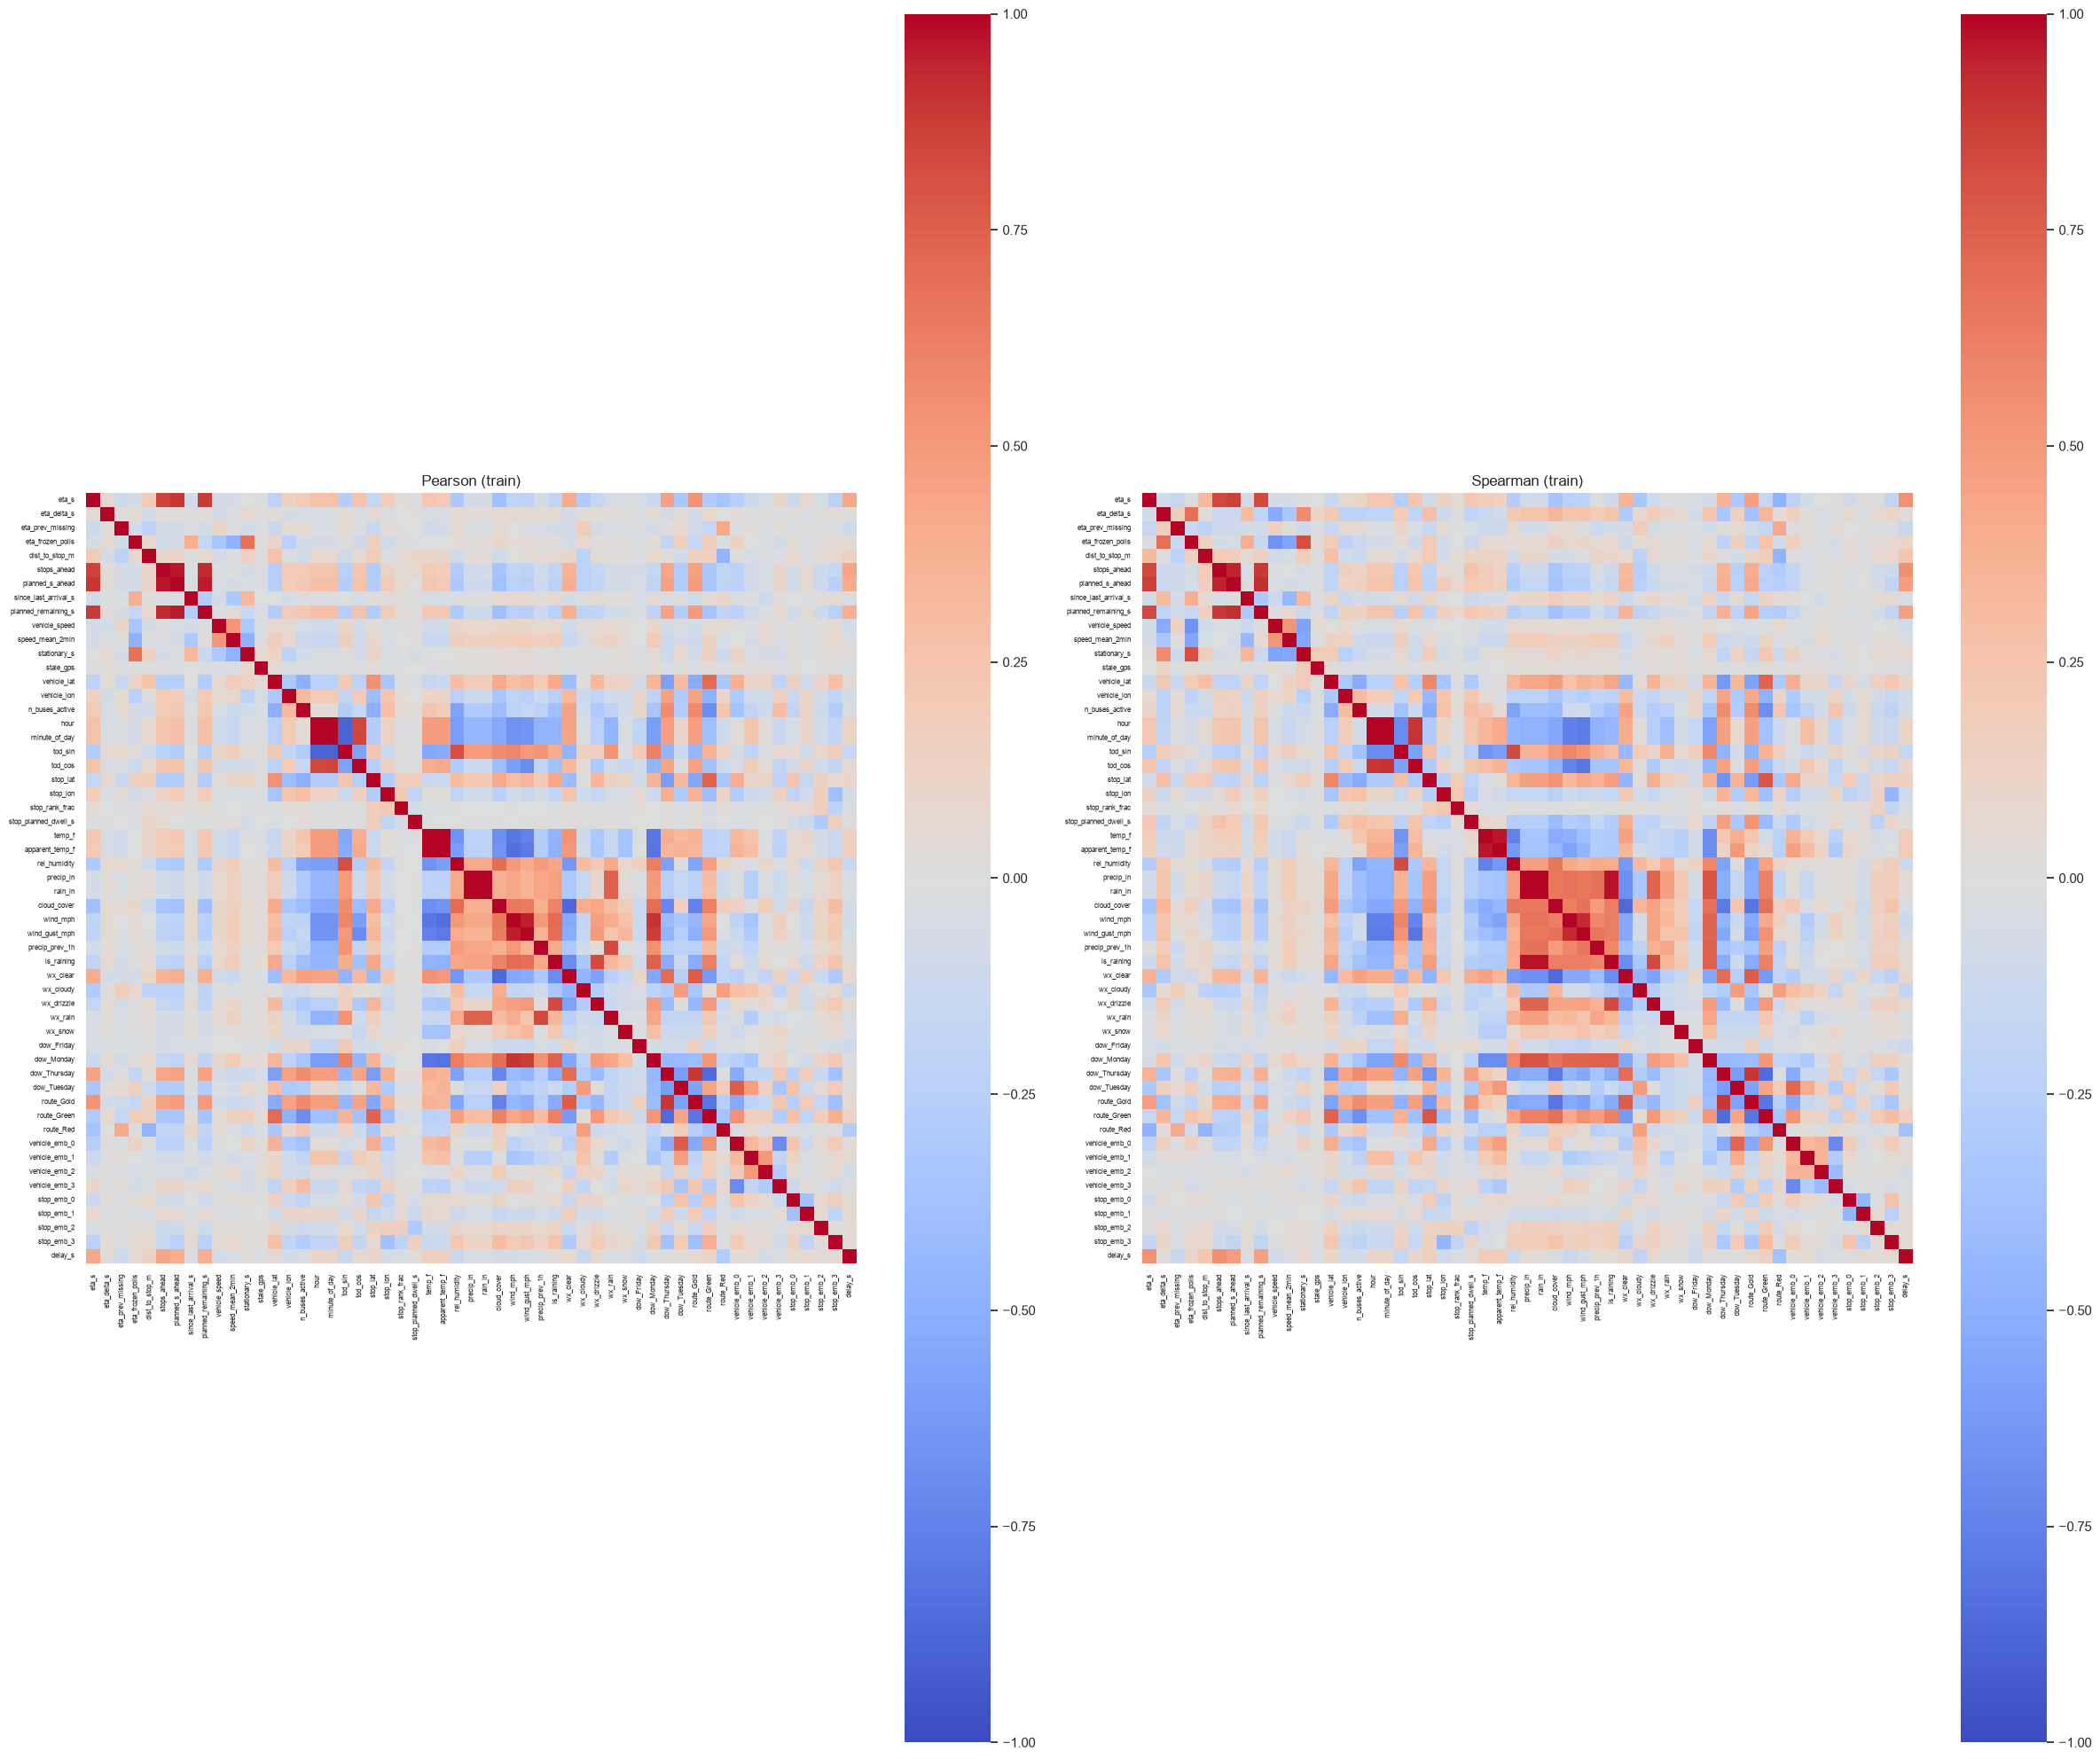

top 15 features by |spearman| with target:
stops_ahead            0.551297
eta_s                  0.539252
planned_s_ahead        0.479498
planned_remaining_s    0.464221
route_Red              0.380697
dist_to_stop_m         0.240122
apparent_temp_f        0.195705
temp_f                 0.192312
wx_cloudy              0.188203
tod_sin                0.169999
route_Green            0.163031
eta_prev_missing       0.155243
stop_lat               0.149308
rel_humidity           0.131720
dow_Friday             0.120276
dtype: float64



spearman high-corr pairs (>=0.95): 5
feature_a       feature_b  spearman
precip_in         rain_in  1.000000
     hour   minute_of_day  0.995193
precip_in      is_raining  0.974018
  rain_in      is_raining  0.974018
   temp_f apparent_temp_f  0.965846

pearson high-corr pairs (>=0.95): 5
      feature_a           feature_b  pearson
      precip_in             rain_in 0.999861
           hour       minute_of_day 0.997270
         temp_f     apparent_temp_f 0.994089
    stops_ahead     planned_s_ahead 0.963505
planned_s_ahead planned_remaining_s 0.955225


In [7]:
corr_cols = features + [target]
pear = train2[corr_cols].corr(method="pearson")
spear = train2[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(24, 20))
sns.heatmap(pear, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0], cbar=True, square=True,
            xticklabels=True, yticklabels=True)
axes[0].set_title("Pearson (train)")
sns.heatmap(spear, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1], cbar=True, square=True,
            xticklabels=True, yticklabels=True)
axes[1].set_title("Spearman (train)")
for ax in axes:
    ax.tick_params(labelsize=6)
plt.tight_layout(); plt.show()

target_spear = train2[features].corrwith(train2[target], method="spearman").abs().sort_values(ascending=False)
print("top 15 features by |spearman| with target:")
print(target_spear.head(15))

sp_pairs = high_corr_pairs(train2, features, method="spearman", thresh=0.95)
pe_pairs = high_corr_pairs(train2, features, method="pearson", thresh=0.95)
print(f"\nspearman high-corr pairs (>=0.95): {len(sp_pairs)}")
print(sp_pairs.to_string(index=False))
print(f"\npearson high-corr pairs (>=0.95): {len(pe_pairs)}")
print(pe_pairs.to_string(index=False))

## E7 — Pruning

`prune_correlated(train2, features, 'delay_s', thresh=0.95, method='spearman')` — for each pair over
threshold, drops the member less correlated with the target. `eta_s` is protected and never dropped.

In [8]:
keep, dropped = prune_correlated(train2, features, target, thresh=0.95, method="spearman")
print(f"kept {len(keep)} / {len(features)} features")
print(f"dropped {len(dropped)}:")
for d in dropped:
    print(f"  {d['dropped']:22s} (kept {d['kept']:22s}) spearman={d['spearman']:.4f}  "
          f"target_corr dropped={d['target_corr_dropped']:.4f}  target_corr kept={d['target_corr_kept']:.4f}")
assert "eta_s" in keep, "eta_s must never be dropped"

kept 50 / 54 features
dropped 4:
  rain_in                (kept precip_in             ) spearman=1.0000  target_corr dropped=0.0444  target_corr kept=0.0444
  minute_of_day          (kept hour                  ) spearman=0.9952  target_corr dropped=0.1133  target_corr kept=0.1152
  precip_in              (kept is_raining            ) spearman=0.9740  target_corr dropped=0.0444  target_corr kept=0.0577
  temp_f                 (kept apparent_temp_f       ) spearman=0.9658  target_corr dropped=0.1923  target_corr kept=0.1957


## E8 — Relationships

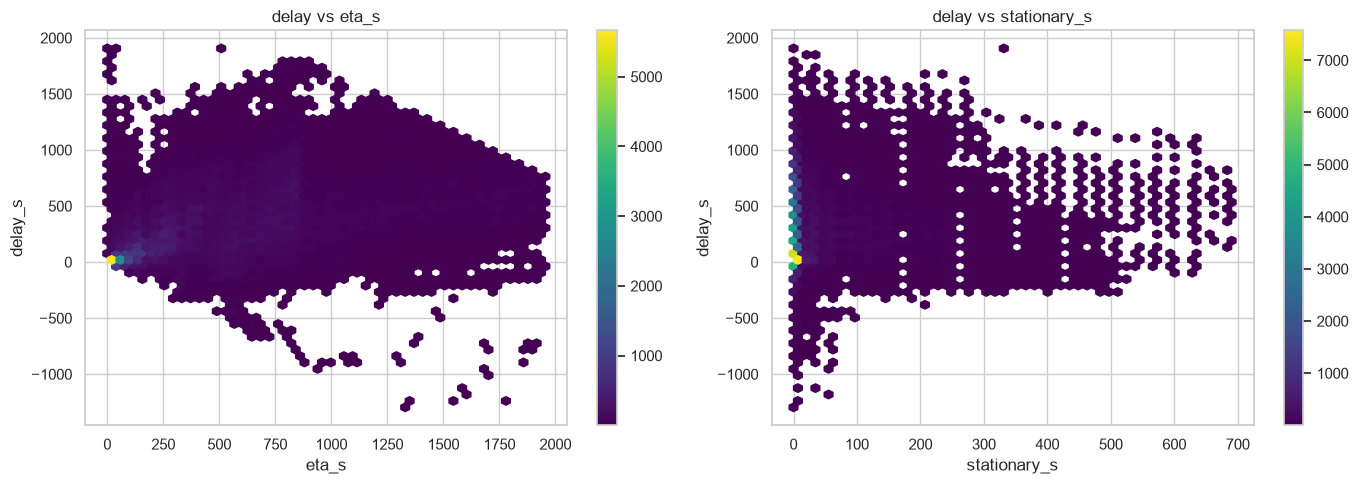

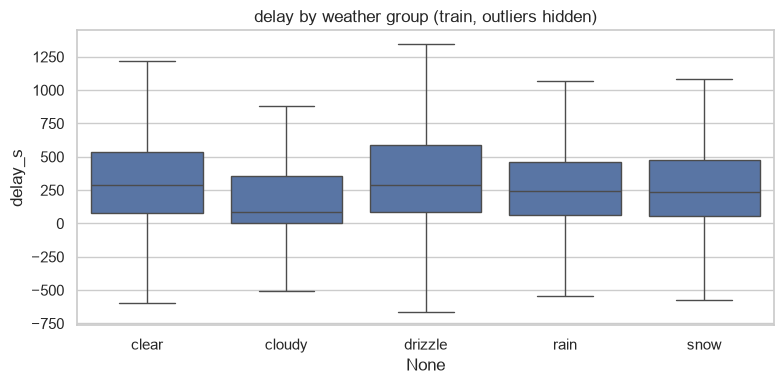

               mean      median  count
clear    345.707624  292.207836  39857
cloudy   208.153537   86.007416  14361
drizzle  356.281723  290.015467  20732
rain     267.304648  246.836768   4390
snow     262.539173  235.024774   1918


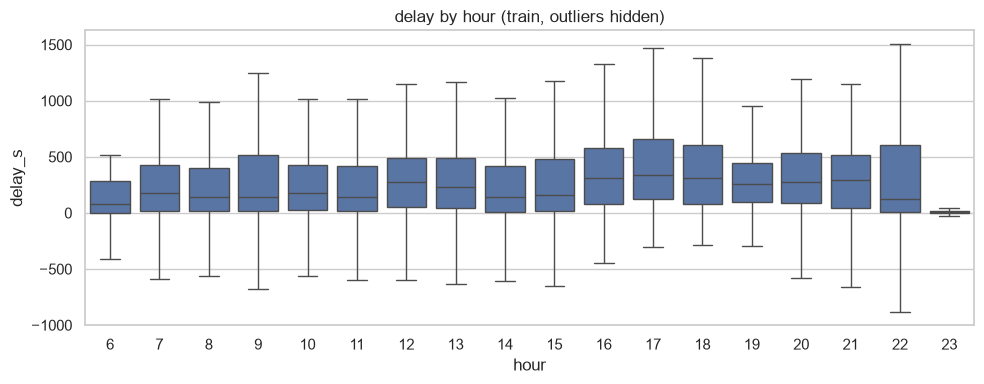


`combined` spans 3 routes (['Gold', 'Green', 'Red']) / 49 stops (route_stop_id) - a per-stop breakdown is only readable for a single route, so it is done in the bus/route EDAs and skipped here per spec.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hb0 = axes[0].hexbin(train2["eta_s"], train2[target], gridsize=50, cmap="viridis", mincnt=1)
axes[0].set_xlabel("eta_s"); axes[0].set_ylabel(target); axes[0].set_title("delay vs eta_s")
fig.colorbar(hb0, ax=axes[0])
hb1 = axes[1].hexbin(train2["stationary_s"], train2[target], gridsize=50, cmap="viridis", mincnt=1)
axes[1].set_xlabel("stationary_s"); axes[1].set_ylabel(target); axes[1].set_title("delay vs stationary_s")
fig.colorbar(hb1, ax=axes[1])
plt.tight_layout(); plt.show()

wx_cols = ["wx_clear", "wx_cloudy", "wx_drizzle", "wx_rain", "wx_snow"]
wx_group = train2[wx_cols].idxmax(axis=1).str.replace("wx_", "", regex=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=wx_group, y=train2[target], ax=ax, showfliers=False)
ax.set_title("delay by weather group (train, outliers hidden)")
plt.tight_layout(); plt.show()
print(train2.groupby(wx_group)[target].agg(["mean", "median", "count"]))

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=train2["hour"], y=train2[target], ax=ax, showfliers=False)
ax.set_title("delay by hour (train, outliers hidden)")
plt.tight_layout(); plt.show()

n_routes = df["route_name"].nunique()
n_stops = df["route_stop_id"].nunique()
print()
print(f"`combined` spans {n_routes} routes ({sorted(df['route_name'].unique().tolist())}) / {n_stops} stops "
      "(route_stop_id) - a per-stop breakdown is only readable for a single route, so it is done in the "
      "bus/route EDAs and skipped here per spec.")

## E9 — Save model-ready dataset (v2)

`save_model_ready` gets the train-only-filtered rows plus **all** test rows (untouched). Constant-feature
checks (both post-filter and on reload) are evaluated **within the train split only**, per v2.

In [10]:
still_const = [c for c in keep if train2[c].nunique(dropna=False) <= 1]
if still_const:
    print("dropping newly-constant-within-train features after outlier filtering:", still_const)
    keep = [c for c in keep if c not in still_const]
else:
    print("no kept feature became constant within train after target-outlier filtering")

notes = {
    "split_rule": "whole service day holdout; test days are those in df.loc[df.split=='test','date'].unique() above; "
                   "cv_group = date (train-only tuning groups)",
    "clough_excluded": "Clough excluded from combined: causal next-stop stop-ID recovery only 75.6% agreement on "
                        "Red (< 80% bar); see datasets/build_report.md. Clough stays in raw_data only.",
    "outlier_rule": "v2: IQR(k=3.0) fences fit on TRAIN target only; rows outside fences dropped from TRAIN ONLY; "
                     "test rows are never filtered by their own label (counted/reported only)",
    "target_fence_lo": lo, "target_fence_hi": hi,
    "train_outliers_dropped": train_out,
    "test_rows_outside_fences_kept": test_out,
    "rows_before": int(len(df)), "rows_after": int(len(df2)),
    "corr_pruning": {"method": "spearman", "thresh": 0.95, "dropped": dropped},
    "newly_constant_after_filter_train": still_const,
    "n_features_before": len(features), "n_features_after": len(keep),
}

out = save_model_ready(DS, df2, keep, notes=notes)
print("saved:", out.shape)

mr = load_model_ready(DS)
assert not mr.X_train.isna().any().any() and not mr.X_test.isna().any().any(), "nulls in model-ready features"
assert not mr.y_train.isna().any() and not mr.y_test.isna().any(), "nulls in target"

const_check_train = [c for c in mr.features if mr.X_train[c].nunique(dropna=False) <= 1]
assert not const_check_train, f"constant-within-train features remain: {const_check_train}"
print("reload OK - 0 nulls, 0 features constant within train")
print("train:", mr.X_train.shape, " test:", mr.X_test.shape)

# v2 check: ALL test rows from the features parquet must be kept (test is never filtered by label)
feat_test_n = int((df["split"] == "test").sum())
assert len(mr.X_test) == feat_test_n, f"test rows changed: model_ready {len(mr.X_test)} vs features {feat_test_n}"
print(f"all test rows kept: model_ready test={len(mr.X_test)} == features test={feat_test_n}")

no kept feature became constant within train after target-outlier filtering


saved: (110399, 59)
reload OK - 0 nulls, 0 features constant within train
train: (81258, 50)  test: (29141, 50)
all test rows kept: model_ready test=29141 == features test=29141


## E10 — Findings

- **Split (v2) & shape**: whole-service-day holdout — test days `2026-03-04` and `2026-03-09`; train days
  `2026-03-03, 03-05, 03-06, 03-10, 03-16` (`cv_group` = date, 5 train groups, 2 test groups). 110,569 rows
  total (train 81,428 / test 29,141, 26.4% test); 54 features, 18 vehicles, 3 routes (Gold 36,218, Green
  60,898, Red 13,453); 0 nulls, 0 constant features, 0 duplicate rows.
- **Test day `2026-03-04` is a Wednesday; no train day is**: train days (Tue 03-03, Thu 03-05, Fri 03-06,
  Tue 03-10, Mon 03-16) never land on a Wednesday, so `dow_Wednesday` was dropped upstream as
  constant-in-train and isn't among the 54 features (only `dow_Monday`/`dow_Tuesday`/`dow_Thursday`/
  `dow_Friday` remain) — all 12,143 `2026-03-04` rows therefore carry an all-zero weekday one-hot
  encoding, an implicit "unseen weekday" the model never trains against.
- **Clough excluded from `combined`**: its causal next-stop stop-ID recovery only agrees with TransLoc's own
  stop 75.6% of the time on Red (below the 80% bar; see `datasets/build_report.md`) — it stays in `raw_data`
  only, so `combined` = Gold + Green + Red.
- **Stale-ETA rows are now dropped at build time**: rows where TransLoc's next-stop pointer still names the
  stop the bus just passed (a stale ETA) are dropped before features are built (see
  `datasets/build_report.md`, "stale-ETA rows") — 526 Gold, 1,665 Green and 11,823 Red raw rows were
  dropped for this; the effect is largest on Red, which also has the lowest causal next-stop agreement
  above.
- **Target is right-skewed**: `delay_s` mean +299.5s, median +229.3s, std 326.3s, skew 1.12, kurtosis 2.51
  (min -1295.5s, max 2697.0s, IQR 42.0s to 484.1s).
- **Delay is route-dependent**: Green (mean +335.3s / median +285.0s) and Gold (+326.7s / +266.4s) run
  consistently later than TransLoc's ETA; Red tracks much more closely (+63.8s / +7.0s).
- **Delay is time-of-day dependent**: worst around 17:00 (mean 420.4s, median 322.0s) and 18:00 (379.0s /
  316.4s); best at 23:00 (mean 38.3s, median 4.0s).
- **Target-outlier rule (v2, train-fit IQR k=3.0)**: fences `[-1340.2, 1910.7]`s. Dropped 170/81,428 train
  rows (0.21%); the same train-fit fences flag (but do **not** drop) 9/29,141 test rows (0.03%) — all
  29,141 test rows are kept; 110,399 of 110,569 rows kept overall.
- **Feature outliers (report-only)**: high per-feature IQR counts are dominated by skewed binary/weather
  flags (`dow_Monday` 23.2%, `wx_cloudy` 17.7%, `route_Red` 10.1%) rather than real anomalies; the core
  continuous schedule/kinematic features (`stops_ahead`, `eta_s`, `planned_s_ahead`, `vehicle_speed`,
  `dist_to_stop_m`, ...) show 0 IQR outliers.
- **Correlation pruning (train, spearman, thresh 0.95)** dropped 4 of 54 features: `rain_in` (r=1.00 with
  `precip_in`), `minute_of_day` (r=0.995 with `hour`), `precip_in` (r=0.974 with `is_raining`), `temp_f`
  (r=0.966 with `apparent_temp_f`) — 50 features kept; `eta_s` protected and never at risk.
- **Strongest target correlates (train spearman)**: `stops_ahead` 0.551, `eta_s` 0.539, `planned_s_ahead`
  0.479, `planned_remaining_s` 0.464, `route_Red` 0.381 — schedule-position features dominate; weather
  trails well behind (`apparent_temp_f` 0.196).
- **Model-ready output**: 110,399 rows x 50 features (+ target + 8 meta cols); train 81,258 / test 29,141 —
  every test row from the features parquet is kept (v2 rule: test is never filtered by its own label);
  `load_model_ready("combined")` reload confirms 0 nulls and 0 features constant within the train split.